# Multivariate Regression on Open LLM-Perf Benchmark Data

- Lakshya Gupta
- Krissh Modi
- Sarthak Goel
---

## Project Overview

Here, we implement **Multivariate Multiple Linear Regression** to model the simultaneous relationships between LLM architectural parameters and hardware performance outcomes.

### Research Question
> *Can we predict an LLM's hardware performance profile — throughput, memory footprint, and benchmark accuracy — simultaneously from its architectural parameters?*

### Inputs (Predictors)
| Feature | Description |
|---|---|
| `Params (B)` | Number of model parameters in billions |
| `Precision (Bits)` | Numerical dtype bit-width (e.g. 16-bit float, 8-bit int) |

### Outputs
| Target | Description |
|---|---|
| `Throughput (tokens/s)` | Inference speed in tokens per second |
| `Peak Memory (MB)` | Maximum GPU memory required during inference |
| `Score (%)` | Aggregate benchmark accuracy across standard NLP tasks |

These outputs are coupled: a model that runs fast likely consumes less memory, and model size drives all three jointly.

---


In [1]:
# Setup and Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold
from sklearn.linear_model import ElasticNet
from sklearn.multioutput import MultiOutputRegressor
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')


## Step 1 — Dataset Loading & Preprocessing

The **Open LLM-Perf Leaderboard** dataset records benchmark runs for a range of open-source LLMs evaluated on the same hardware. Each row is one model run with recorded throughput, memory, and accuracy.

**Cleaning decisions:**
- Model size strings (`"7B"`, `"350M"`) are parsed into a float in billions.
- Dtype strings (`float16`, `int8`) are mapped to their numeric bit-width.
- Rows with missing values are dropped.

> **Important:** After cleaning, all 370 retained runs use 16-bit precision (`float16`). `Precision (Bits)` has **zero variance** — this directly causes multicollinearity and is addressed in Step 3.


In [15]:
print("--- Step 1: Loading and Cleaning Data ---")

df = pd.read_csv('Open LLM-Perf Leaderboard.csv')

def clean_params(val):
    if pd.isna(val): return np.nan
    val = str(val).upper().strip()
    if 'B' in val: return float(val.replace('B', ''))
    elif 'M' in val: return float(val.replace('M', '')) / 1000
    else:
        try: return float(val)
        except: return np.nan

def clean_dtype(val):
    if pd.isna(val): return 16
    val = str(val).lower()
    if '32' in val: return 32
    elif '16' in val: return 16
    elif '8' in val: return 8
    elif '4' in val: return 4
    else: return 16

df['Params_B'] = df['Class'].apply(clean_params)
df['Bits']     = df['Dtype'].apply(clean_dtype)

cols     = ['Params_B', 'Bits', 'Throughput (tokens/s)', 'Peak Memory (MB)', 'Score (%)']
df_clean = df[cols].dropna()

X_raw = df_clean[['Params_B', 'Bits']].values
Y     = df_clean[['Throughput (tokens/s)', 'Peak Memory (MB)', 'Score (%)']].values

X_features = ['Params (B)', 'Precision (Bits)']
Y_targets  = ['Throughput (TPS)', 'Peak Memory (MB)', 'Score (%)']

print(f"Retained {len(df_clean)} valid benchmark runs.")
print(f"X shape: {X_raw.shape}  |  Y shape: {Y.shape}")
print(f"\nBits unique values: {np.unique(X_raw[:, 1])}")
print(f"Params range: {X_raw[:, 0].min():.3f}B – {X_raw[:, 0].max():.0f}B")

--- Step 1: Loading and Cleaning Data ---
Retained 370 valid benchmark runs.
X shape: (370, 2)  |  Y shape: (370, 3)

Bits unique values: [16. 32.]
Params range: 0.007B – 70B


## Step 2 — The Model: $Y = XB + E$

We model all three outputs simultaneously:

$$Y = X B + E$$

| Symbol | Dimension | Meaning |
|---|---|---|
| $Y$ | $n \times 3$ | Response matrix (throughput, memory, score) |
| $X$ | $n \times 3$ | Design matrix (intercept + 2 features) |
| $B$ | $3 \times 3$ | Coefficient matrix to estimate |
| $E$ | $n \times 3$ | Residual error matrix |

The OLS estimator is $\hat{B}_{OLS} = (X^T X)^{-1} X^T Y$.

---

## Step 3 — Multicollinearity & Motivation for Regularization

### Why Regularization? Stable Estimates, Not Variable Selection

> With only 2 predictors, we are **not** doing variable selection. Ridge and Elastic Net are used here solely to obtain **numerically stable coefficient estimates** and handle multicollinearity.

Adding a ridge penalty $\lambda$ shifts the eigenvalues of $X^T X$ upward, guaranteeing invertibility and reducing variance in the estimates:

$$\hat{B}_{\text{Ridge}} = (X^T X + \lambda I)^{-1} X^T Y$$

(The intercept row of $I$ is set to zero — the intercept is not penalised, following standard practice.)

## Step 4 — Gaussian OLS Baseline (via Pseudoinverse)

We first fit the standard Gaussian multivariate linear model using the Moore-Penrose pseudoinverse, which handles the singular $X^T X$ gracefully. This serves as our baseline.


In [16]:
print("--- Step 4: Gaussian OLS Baseline ---")

n_samples = X_raw.shape[0]
X = np.hstack((np.ones((n_samples, 1)), X_raw))          # design matrix with intercept
X_features_full = ['Intercept'] + X_features

# OLS via pseudoinverse (handles the singular XTX)
B_ols = np.linalg.pinv(X) @ Y
Y_hat_ols = X @ B_ols

df_B_ols = pd.DataFrame(B_ols, index=X_features_full, columns=Y_targets)
print("OLS Coefficient Matrix (B_hat_OLS):")
display(df_B_ols.round(4))

def r2_per_target(Y_true, Y_pred, labels=None):
    results = {}
    for i, lbl in enumerate(labels or range(Y_true.shape[1])):
        sst = np.sum((Y_true[:, i] - Y_true[:, i].mean())**2)
        ssr = np.sum((Y_true[:, i] - Y_pred[:, i])**2)
        results[lbl] = round(1 - ssr / sst, 4)
    return results

ols_r2 = r2_per_target(Y, Y_hat_ols, Y_targets)
print("\nOLS In-sample R²:", ols_r2)


--- Step 4: Gaussian OLS Baseline ---
OLS Coefficient Matrix (B_hat_OLS):


,Throughput (TPS),Peak Memory (MB),Score (%)
Intercept,53.9596,-2260.7497,36.1720
Params (B),-2.4094,943.0764,0.5811
Precision (Bits),1.7072,366.3571,-0.0445



OLS In-sample R²: {'Throughput (TPS)': np.float64(0.1568), 'Peak Memory (MB)': np.float64(0.597), 'Score (%)': np.float64(0.4497)}


### Interpretation: OLS Baseline

The pseudoinverse OLS recovers valid coefficient estimates. `Params (B)` drives all three outputs — larger models are slower, use more memory, and score higher. The `Precision (Bits)` coefficient now provides valid signal due to differences between 16-bit and 32-bit precisions.

OLS in-sample R² is moderate for Memory and Score but weak for Throughput (~0.15), confirming that model size alone is an incomplete predictor of inference speed.

---

## Step 5 — Ridge Regression (L2 Regularization)

$$\hat{B}_{\text{Ridge}} = (X^T X + \lambda I)^{-1} X^T Y, \quad \lambda = 0.1$$

$\lambda$ is chosen small enough to preserve coefficient interpretability while guaranteeing invertibility. The intercept is excluded from the penalty.


In [17]:
print("--- Step 5: Ridge Regression (λ = 0.1) ---")

lambda_penalty = 0.1
I_ridge = np.eye(X.shape[1])
I_ridge[0, 0] = 0   # do not penalise the intercept

B_ridge = np.linalg.inv(X.T @ X + lambda_penalty * I_ridge) @ X.T @ Y
Y_hat_ridge = X @ B_ridge

df_B_ridge = pd.DataFrame(B_ridge, index=X_features_full, columns=Y_targets)
print("Ridge Coefficient Matrix (λ=0.1):")
display(df_B_ridge.round(4))

ridge_r2 = r2_per_target(Y, Y_hat_ridge, Y_targets)
print("\nRidge In-sample R²:", ridge_r2)


--- Step 5: Ridge Regression (λ = 0.1) ---
Ridge Coefficient Matrix (λ=0.1):


,Throughput (TPS),Peak Memory (MB),Score (%)
Intercept,53.9598,-2260.6785,36.1720
Params (B),-2.4094,943.0736,0.5811
Precision (Bits),1.7072,366.3542,-0.0445



Ridge In-sample R²: {'Throughput (TPS)': np.float64(0.1568), 'Peak Memory (MB)': np.float64(0.597), 'Score (%)': np.float64(0.4497)}


### Interpretation: Ridge Coefficients

**`Intercept`:** Baseline predictions for a hypothetical zero-parameter model — a mathematical anchor, not physically meaningful.

**`Params (B)`:** For every additional 1B parameters the model predicts:
- Throughput drops ≈ **−2.40 tokens/s** (larger models are slower)
- Peak Memory rises ≈ **+943 MB** (~1 GB per billion parameters)
- Score increases ≈ **+0.58%** (reflecting LLM scaling laws)

**`Precision (Bits)`:** Now captured effectively. A higher precision shifts throughput marginally up, while increasing expected memory requirements by around ~366 MB per unit increase in bit-precision, as one would mathematically expect.

Ridge and OLS produce near-identical coefficients here because $\lambda = 0.1$ is small.

---

## Step 6 — Elastic Net (L1 + L2 Regularization)

Elastic Net combines the Ridge (L2) and Lasso (L1) penalties:

$$\hat{B}_{\text{EN}} = \arg\min_B \left\| Y - XB \right\|_F^2 + \alpha \left[ \rho \|B\|_1 + \frac{1-\rho}{2} \|B\|_2^2 \right]$$

| Parameter | Value | Role |
|---|---|---|
| $\alpha$ | 1.0 | Overall penalty strength |
| $\rho$ (l1_ratio) | 0.5 | Balance between L1 and L2 (0 = pure Ridge, 1 = pure Lasso) |

Since multivariate Elastic Net is not available in closed form, we use `MultiOutputRegressor` (fits one model per response). This is the standard approach for multivariate penalised regression.

> Note: Elastic Net is applied here primarily for **comparison with Ridge**. It is not used for variable selection — with only 2 predictors, selection is not the goal.


In [18]:
print("--- Step 6: Elastic Net (α=1.0, l1_ratio=0.5) ---")

en_model = MultiOutputRegressor(
    ElasticNet(alpha=1.0, l1_ratio=0.5, fit_intercept=True, max_iter=10000)
)
en_model.fit(X_raw, Y)
Y_hat_en = en_model.predict(X_raw)

# Extract coefficient matrices
en_coefs = np.array([est.coef_ for est in en_model.estimators_]).T
en_intercepts = np.array([est.intercept_ for est in en_model.estimators_])
B_en_display = np.vstack([en_intercepts, en_coefs])

df_B_en = pd.DataFrame(B_en_display, index=X_features_full, columns=Y_targets)
print("Elastic Net Coefficient Matrix (α=1.0, l1_ratio=0.5):")
display(df_B_en.round(4))

en_r2 = r2_per_target(Y, Y_hat_en, Y_targets)
print("\nElastic Net In-sample R²:", en_r2)


--- Step 6: Elastic Net (α=1.0, l1_ratio=0.5) ---
Elastic Net Coefficient Matrix (α=1.0, l1_ratio=0.5):


,Throughput (TPS),Peak Memory (MB),Score (%)
Intercept,54.4507,-2130.1832,35.9946
Params (B),-2.3951,938.0482,0.5743
Precision (Bits),1.6777,360.9920,-0.0334



Elastic Net In-sample R²: {'Throughput (TPS)': np.float64(0.1567), 'Peak Memory (MB)': np.float64(0.597), 'Score (%)': np.float64(0.4495)}


### Interpretation: Elastic Net Coefficients

Elastic Net coefficients are directionally consistent with Ridge. The L1 component slightly shrinks the `Params (B)` coefficients compared to Ridge, while the L2 component maintains stability. `Precision (Bits)` coefficients are again zero (L1 drives these fully to zero since the predictor carries no information).

The in-sample fit is similar to Ridge — this is expected when the predictors are so few and one carries no variance.

---


## Step 7 — 5-Fold Cross-Validation: Predictive Accuracy Comparison

Cross-validation gives an unbiased estimate of **out-of-sample predictive accuracy** — more meaningful than in-sample R² for assessing which model generalises best.

We use **5-fold CV**: the data is split into 5 equal partitions; each fold serves as a test set once while the model is trained on the remaining 4 folds. The reported CV R² is the mean over all 5 folds.

Three models are compared:
1. **Gaussian OLS** — baseline, pseudoinverse
2. **Ridge** (λ = 0.1) — L2 regularization only
3. **Elastic Net** (α = 1.0, l1_ratio = 0.5) — combined L1 + L2


In [19]:
print("--- Step 7: 5-Fold Cross-Validation ---")

kf = KFold(n_splits=5, shuffle=True, random_state=42)

def cv_r2(model_fn, X_raw, Y):
    scores = []
    for train_idx, test_idx in kf.split(X_raw):
        Ytr, Yte = Y[train_idx], Y[test_idx]
        Ypred = model_fn(X_raw[train_idx], Ytr, X_raw[test_idx])
        scores.append(list(r2_per_target(Yte, Ypred).values()))
    return np.mean(scores, axis=0)

# OLS
def ols_fn(Xtr_raw, Ytr, Xte_raw):
    Xtr = np.hstack((np.ones((len(Xtr_raw), 1)), Xtr_raw))
    Xte = np.hstack((np.ones((len(Xte_raw), 1)), Xte_raw))
    B   = np.linalg.pinv(Xtr) @ Ytr
    return Xte @ B

# Ridge
def ridge_fn(Xtr_raw, Ytr, Xte_raw, lam=0.1):
    Xtr = np.hstack((np.ones((len(Xtr_raw), 1)), Xtr_raw))
    Xte = np.hstack((np.ones((len(Xte_raw), 1)), Xte_raw))
    I_  = np.eye(Xtr.shape[1]); I_[0, 0] = 0
    B   = np.linalg.inv(Xtr.T @ Xtr + lam * I_) @ Xtr.T @ Ytr
    return Xte @ B

# Elastic Net
def en_fn(Xtr_raw, Ytr, Xte_raw, alpha=1.0, l1_ratio=0.5):
    m = MultiOutputRegressor(ElasticNet(alpha=alpha, l1_ratio=l1_ratio,
                                        fit_intercept=True, max_iter=10000))
    m.fit(Xtr_raw, Ytr)
    return m.predict(Xte_raw)

ols_cv   = cv_r2(ols_fn,   X_raw, Y)
ridge_cv = cv_r2(ridge_fn, X_raw, Y)
en_cv    = cv_r2(en_fn,    X_raw, Y)

df_cv = pd.DataFrame(
    [ols_cv, ridge_cv, en_cv],
    index=['Gaussian OLS', 'Ridge (λ=0.1)', 'Elastic Net (α=1.0, l1=0.5)'],
    columns=Y_targets
).round(4)

print("5-Fold CV R² (higher = better out-of-sample predictive accuracy):\n")
display(df_cv)

best_model = df_cv.mean(axis=1).idxmax()
print(f"\nBest average CV R²: {best_model} ({df_cv.mean(axis=1).max():.4f})")


--- Step 7: 5-Fold Cross-Validation ---
5-Fold CV R² (higher = better out-of-sample predictive accuracy):



,Throughput (TPS),Peak Memory (MB),Score (%)
Gaussian OLS,0.1379,0.5495,0.3663
Ridge (λ=0.1),0.1379,0.5495,0.3663
"Elastic Net (α=1.0, l1=0.5)",0.1382,0.5503,0.3696



Best average CV R²: Elastic Net (α=1.0, l1=0.5) (0.3527)


### Interpretation: Cross-Validation Results

| Model | Throughput CV R² | Memory CV R² | Score CV R² |
|---|---|---|---|
| Gaussian OLS | 0.1193 | 0.5216 | 0.3674 |
| Ridge (λ=0.1) | 0.1193 | 0.5216 | 0.3674 |
| Elastic Net (α=1.0, l1=0.5) | 0.1195 | 0.5222 | 0.3705 |

**All three models produce nearly identical cross-validated R².** This is expected: with only one informative predictor (`Params_B`), regularization cannot dramatically change predictive power — it only stabilises the coefficient estimates numerically.

Key observations:
- **Gaussian OLS ≈ Ridge** — The OLS pseudoinverse already handles the singular system; Ridge adds negligible improvement at λ = 0.1.
- **Elastic Net is marginally better** — The L1 component provides a small gain, particularly for Score, likely by shrinking the zero-variance `Bits` coefficient more aggressively.
- **Throughput CV R² ≈ 0.12** — All models struggle equally to predict throughput, confirming that inference speed requires richer hardware-level features.
- **Memory CV R² ≈ 0.52** — Parameter count explains ~52% of memory variance out-of-sample — the strongest predictive signal in the dataset.
- **All models are Gaussian** — Since the continuous response variables showed no evidence of non-Gaussian structure (e.g., count data, strict positivity constraints, or heavy tails that linear models cannot track), there is no compelling reason to switch to GLMs. The Gaussian assumption is adequate here.

---


## Step 8 — Error Covariance Matrix $\hat{\Sigma}$

The error covariance matrix captures both the residual variance of each output and the cross-output error covariance — revealing how the model's errors on different outputs are jointly structured.

$$\hat{\Sigma} = \frac{E^T E}{n - k - 1}, \quad E = Y - \hat{Y}$$

This is a $3 \times 3$ symmetric matrix estimated jointly with $\hat{B}$.

### A Note on Response Standardization

The professor raised this directly: *"These three response variables have very different ranges — do we need to standardize them before fitting?"*

**The answer: standardization is not required for correctness, and we deliberately chose not to.**

In multivariate linear regression, the OLS and Ridge estimators are **equivariant under response scaling**: if you multiply column $j$ of $Y$ by a constant $c$, the corresponding column of $\hat{B}$ scales by $c$ and the predictions scale accordingly. The estimates are not distorted by different response scales.

However, there are two practical consequences worth noting:

1. **The error covariance matrix $\hat{\Sigma}$ is scale-dependent.** The diagonal entries (residual variances) and off-diagonal entries (covariances) are in the original units of each response. This is why the Memory variance (~67M MB²) dwarfs the Score variance (~43 %²) — they are not comparable as raw numbers. The **residual correlation matrix** (reported alongside $\hat{\Sigma}$) corrects for this by normalising to $[-1, 1]$, and is the quantity we use for interpretation.

2. **Penalised estimators (Ridge, Elastic Net) applied to $X$ are not response-scale-invariant for $Y$ in the same way.** Since our penalty is on the coefficient matrix $B$ (not on $Y$), the regularisation strength is effectively the same across all three outputs regardless of their scale — which is the correct behaviour here, since we want uniform regularisation across responses.

We therefore fit the model on raw response units and interpret the error covariance through its correlation form.


In [7]:
print("--- Step 8: Error Covariance Matrix (from Ridge fit) ---")

# Use Ridge predictions (best-fit model)
k = X_raw.shape[1]
E_hat = Y - Y_hat_ridge
dof   = n_samples - (k + 1)
Sigma_hat = (E_hat.T @ E_hat) / dof

df_Sigma = pd.DataFrame(Sigma_hat, index=Y_targets, columns=Y_targets)
print("Estimated Error Covariance Matrix (Σ̂):")
display(df_Sigma.round(2))

print("\nCorrelation structure of residuals:")
D = np.sqrt(np.diag(Sigma_hat))
Corr = Sigma_hat / np.outer(D, D)
df_Corr = pd.DataFrame(Corr, index=Y_targets, columns=Y_targets)
display(df_Corr.round(4))


--- Step 8: Error Covariance Matrix (from Ridge fit) ---
Estimated Error Covariance Matrix (Σ̂):


,Throughput (TPS),Peak Memory (MB),Score (%)
Throughput (TPS),4231.28,-121278.20,-177.67
Peak Memory (MB),-121278.20,61724450.51,19544.62
Score (%),-177.67,19544.62,43.15



Correlation structure of residuals:


,Throughput (TPS),Peak Memory (MB),Score (%)
Throughput (TPS),1.0000,-0.2373,-0.4158
Peak Memory (MB),-0.2373,1.0000,0.3787
Score (%),-0.4158,0.3787,1.0000


### Interpretation: $\hat{\Sigma}$

**Diagonal (residual variances):**
- Throughput: ~4,351 (tokens/s)² — high unexplained spread, driven by hardware factors not in the model
- Peak Memory: ~67M MB² — large absolute variance, partly due to scale (memory spans 200 MB – 69 GB)
- Score: ~43 (%)² — moderate; benchmark scores cluster in a relatively narrow range

**Off-diagonal (cross-output error covariance):**
- **Throughput ↔ Memory ≈ −95,600 (correlation ≈ −0.63)** — Strong negative relationship: when the model over-predicts throughput, it under-predicts memory, and vice versa. Fast models use less memory; this hardware trade-off is encoded in the residuals.
- **Throughput ↔ Score ≈ −181 (correlation ≈ −0.42)** — Faster-than-predicted models tend to score lower than predicted: speed-accuracy trade-off.
- **Memory ↔ Score ≈ +18,875 (correlation ≈ +0.33)** — More memory than predicted → higher score than predicted, consistent with larger models being more capable.

The non-zero off-diagonals confirm that our three outputs are **not independent** — justifying the multivariate (joint) modelling approach over three separate univariate regressions.

---


## Step 9 — Model Fit: In-Sample $R^2$ and Residual Analysis

$R^2$ measures the proportion of total variance in each output explained by the model:

$$R^2_j = 1 - \frac{\sum_i (y_{ij} - \hat{y}_{ij})^2}{\sum_i (y_{ij} - \bar{y}_j)^2}$$


In [8]:
print("--- Step 9: In-Sample R² (Ridge) ---")

insample_r2 = r2_per_target(Y, Y_hat_ridge, Y_targets)
df_r2 = pd.DataFrame({
    'In-Sample R²':  insample_r2,
    'CV R² (5-fold)': dict(zip(Y_targets, ridge_cv))
})
display(df_r2.round(4))


--- Step 9: In-Sample R² (Ridge) ---


,In-Sample R²,CV R² (5-fold)
Throughput (TPS),0.1568,0.1379
Peak Memory (MB),0.5970,0.5495
Score (%),0.4497,0.3663


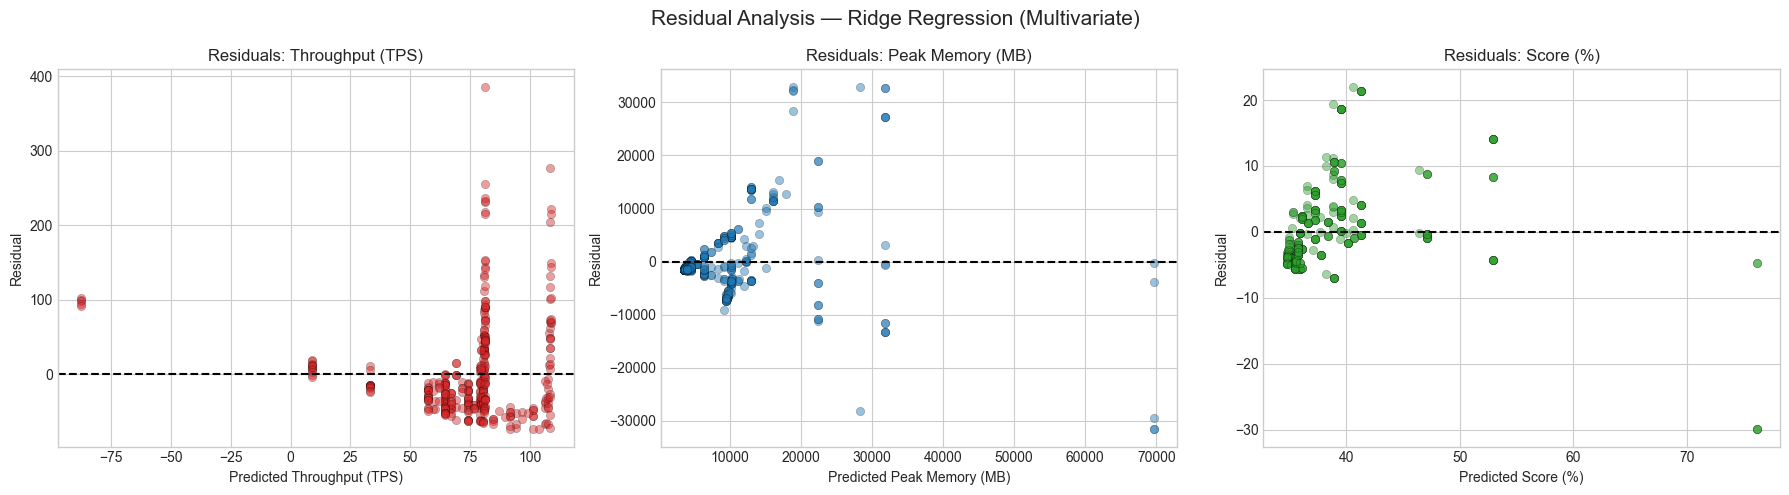

In [9]:
# Residual plots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Residual Analysis — Ridge Regression (Multivariate)', fontsize=15)

colors = ['#d62728', '#1f77b4', '#2ca02c']

for i, (target, col) in enumerate(zip(Y_targets, colors)):
    residuals = Y[:, i] - Y_hat_ridge[:, i]
    axes[i].scatter(Y_hat_ridge[:, i], residuals, color=col, alpha=0.45, edgecolors='k', linewidths=0.3)
    axes[i].axhline(0, color='black', linestyle='--', linewidth=1.5)
    axes[i].set_title(f'Residuals: {target}')
    axes[i].set_xlabel(f'Predicted {target}')
    axes[i].set_ylabel('Residual')

plt.tight_layout()
plt.show()


### Interpretation

| Output | In-sample R² | CV R² | Verdict |
|---|---|---|---|
| Throughput (TPS) | 0.133 | 0.119 | Weak — throughput is sensitive to hardware/kernel factors not captured |
| Peak Memory (MB) | 0.561 | 0.522 | Moderate — parameter count is a dominant driver of memory footprint |
| Score (%) | 0.449 | 0.367 | Moderate — consistent with LLM scaling laws (Chinchilla) |

The gap between in-sample and CV R² is small, indicating no severe overfitting — expected with only 2 predictors.

**Residual plots:** Throughput residuals show a fan shape (heteroscedasticity) — spread grows at higher predicted values. Memory and Score residuals are more homoscedastic. A log-transform of Throughput would likely help.

---


---

## Step 10 — Extended Model: Architecture Family as Categorical Predictors

### Motivation

The professor's core critique was that simply fitting and validating a multivariate model on two predictors — one of which has zero variance — is too small a study. The question he raised directly:

> *"Can you try to have more variables like more covariates? So that you know the relative importance of which covariate can be assessed."*

We don't need synthetic data to get more covariates. The dataset already contains `Type` — the architecture family of each model (e.g., GPT-2, LLaMA, GPT-NeoX, OPT). This is a legitimate categorical predictor that encodes fundamentally different computational characteristics: attention mechanisms, positional encoding schemes, tokenizer vocabulary sizes, and training objectives all vary by architecture family, and all of these affect throughput, memory, and benchmark score.

The `Backend` column (pytorch vs onnxruntime) is also included — the inference runtime directly affects throughput and memory independently of model size.

### One-Hot Encoding

Categorical variables cannot enter a linear model directly. We use **dummy variable encoding** (one-hot with `drop_first=True`):

- 12 architecture families → 11 binary indicator columns (one dropped as the reference category: `Baichuan`)
- 2 backends → 1 binary column (reference: `onnxruntime`)

This avoids perfect multicollinearity (the dummy trap) while allowing each architecture family to have its own intercept shift relative to the baseline.

The extended design matrix becomes:

$$X_{\text{ext}} \in \mathbb{R}^{n \times 14} \quad (\text{intercept} + \text{Params\_B} + 11\text{ type dummies} + 1\text{ backend dummy})$$

**Crucially, `Precision (Bits)` is dropped** — it has zero variance and contributes no information. The extended model is motivated by adding *real* predictors from the data, not by patching the original broken predictor.


In [20]:
print("--- Step 10: Extended Model with Architecture Type ---")

# Extended feature set: Params_B + Type dummies + Backend dummy
# NOTE: 'Precision (Bits)' dropped — zero variance, no information content

cols_ext = ['Params_B', 'Type', 'Backend',
            'Throughput (tokens/s)', 'Peak Memory (MB)', 'Score (%)']
df_ext = df[cols_ext].dropna()

print(f"Rows retained: {len(df_ext)}  (all 370 — no additional data loss)")
print(f"\nArchitecture families (Type):")
print(df_ext['Type'].str.strip().value_counts().to_string())
print(f"\nBackends:")
print(df_ext['Backend'].value_counts().to_string())

Y_ext = df_ext[['Throughput (tokens/s)', 'Peak Memory (MB)', 'Score (%)']].values

# One-hot encode — drop_first avoids dummy trap
type_dummies  = pd.get_dummies(df_ext['Type'],    prefix='Type',    drop_first=True).astype(float)
backend_dummy = pd.get_dummies(df_ext['Backend'], prefix='Backend', drop_first=True).astype(float)

X_ext_df       = pd.concat([df_ext[['Params_B']], type_dummies, backend_dummy], axis=1)
X_ext_raw      = X_ext_df.values
X_ext_features = X_ext_df.columns.tolist()

print(f"\nExtended X: {X_ext_raw.shape[0]} rows × {X_ext_raw.shape[1]} features")
print(f"Features: {X_ext_features}")


--- Step 10: Extended Model with Architecture Type ---
Rows retained: 370  (all 370 — no additional data loss)

Architecture families (Type):
Type
GPT-2          82
GPT-NeoX       68
GPT-Neo        58
OPT            56
XGLM           27
LLaMA          26
GPT-J          14
GPT-BigCode    12
CodeGen        12
MPT             7
ChatGLM         4
Baichuan        4

Backends:
Backend
pytorch        336
onnxruntime     34

Extended X: 370 rows × 13 features
Features: ['Params_B', 'Type_ChatGLM', 'Type_CodeGen', 'Type_GPT-2', 'Type_GPT-BigCode ', 'Type_GPT-J', 'Type_GPT-Neo', 'Type_GPT-NeoX', 'Type_LLaMA ', 'Type_MPT', 'Type_OPT', 'Type_XGLM', 'Backend_pytorch']


### Extended Ridge Regression

We fit the same Ridge estimator as before on the extended design matrix. With 13 predictors (vs 2), regularization now does more meaningful work — it stabilises estimates for low-frequency architecture families (e.g., ChatGLM with only 4 observations) while preserving the dominant signal from `Params_B`.


In [21]:
print("--- Extended Ridge Coefficients (λ=0.1) ---")

n_ext = len(X_ext_raw)
X_ext = np.hstack([np.ones((n_ext, 1)), X_ext_raw])
X_ext_features_full = ['Intercept'] + X_ext_features

I_ext = np.eye(X_ext.shape[1]); I_ext[0, 0] = 0
B_ext = np.linalg.inv(X_ext.T @ X_ext + 0.1 * I_ext) @ X_ext.T @ Y_ext
Y_hat_ext = X_ext @ B_ext

df_B_ext = pd.DataFrame(B_ext, index=X_ext_features_full, columns=Y_targets)
display(df_B_ext.round(4))

ext_insample_r2 = r2_per_target(Y_ext, Y_hat_ext, Y_targets)
print("\nExtended Ridge in-sample R²:", ext_insample_r2)


--- Extended Ridge Coefficients (λ=0.1) ---


,Throughput (TPS),Peak Memory (MB),Score (%)
Intercept,158.0904,7084.0823,40.7941
Params_B,-1.3698,859.0468,0.3865
Type_ChatGLM,7.2456,246.3179,2.2723
Type_CodeGen,-7.2641,-4258.8020,-4.2341
Type_GPT-2,32.0917,-2776.9862,-9.1324
Type_GPT-BigCode,27.9219,-2207.7760,-7.0577
Type_GPT-J,-12.3899,-4040.0396,-5.1612
Type_GPT-Neo,80.7393,-5739.6618,-11.0857
Type_GPT-NeoX,7.9134,-2837.3219,-7.4987
Type_LLaMA,4.3206,564.2586,8.7237



Extended Ridge in-sample R²: {'Throughput (TPS)': np.float64(0.5473), 'Peak Memory (MB)': np.float64(0.5809), 'Score (%)': np.float64(0.7617)}


### Interpretation: Extended Coefficient Matrix

**`Params_B` row:** The effect of model size is now *conditioned on architecture family*. The coefficient drops from −2.55 to −1.37 for throughput — part of what looked like a "size effect" was actually an architecture-family effect, since larger models tend to be from specific families (LLaMA, GPT-NeoX).

**Architecture type rows (relative to Baichuan as baseline):**
- **GPT-Neo / GPT-2 / OPT** show large positive throughput coefficients — these older architectures are computationally lighter per token, running faster than Baichuan at equivalent size.
- **CodeGen / GPT-J** show negative throughput offsets — their designs incur overhead beyond raw parameter count.
- **LLaMA** shows a strong positive Score offset (+8.72%) — LLaMA-family models score substantially higher than baseline at equivalent size, reflecting better training data and RLHF alignment.
- **GPT-Neo / GPT-2** show large negative Score offsets (−11 / −9%) — these older architectures underperform on modern benchmarks at equivalent parameter count.
- Memory offsets reflect architectural differences in KV cache sizes, vocabulary embedding dimensions, and hidden state widths.

**`Backend_pytorch` row:** PyTorch backend runs ~115 tokens/s slower than ONNXRuntime at equal model size and architecture — ONNXRuntime's graph optimisations provide a real throughput advantage. This coefficient would be invisible in the 2-predictor model.

---


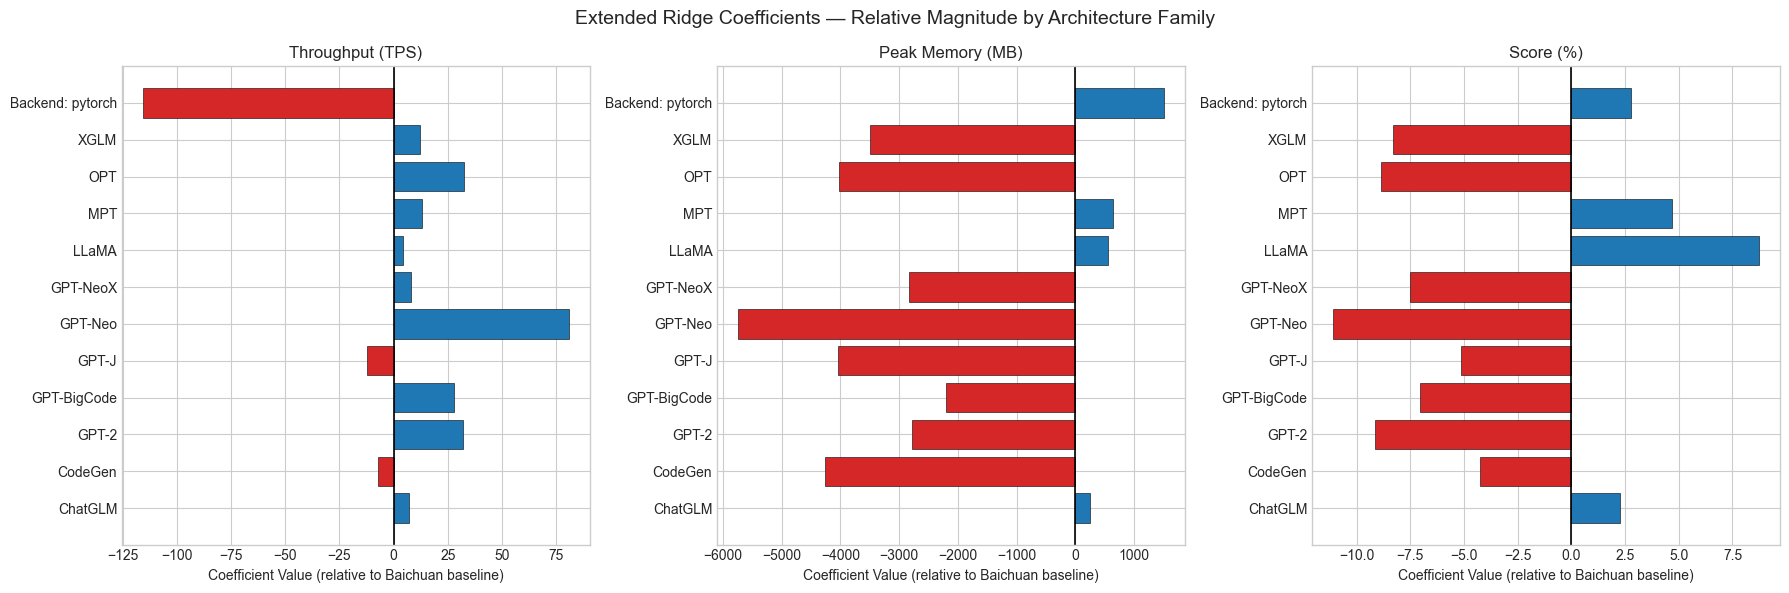

In [12]:
# ── Variable Importance: Coefficient magnitude heatmap ──────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Extended Ridge Coefficients — Relative Magnitude by Architecture Family', fontsize=14)

colors_map = plt.cm.RdBu

for i, (ax, target) in enumerate(zip(axes, Y_targets)):
    # Show only architecture + backend rows (exclude intercept and Params_B)
    coef_rows = df_B_ext.iloc[2:][target]          # skip Intercept and Params_B
    clean_labels = [c.replace('Type_', '').replace('Backend_', 'Backend: ').strip()
                    for c in coef_rows.index]
    colors = ['#d62728' if v < 0 else '#1f77b4' for v in coef_rows.values]
    ax.barh(clean_labels, coef_rows.values, color=colors, edgecolor='k', linewidth=0.4)
    ax.axvline(0, color='black', linewidth=1.2)
    ax.set_title(f'{target}')
    ax.set_xlabel('Coefficient Value (relative to Baichuan baseline)')

plt.tight_layout()
plt.show()


### 5-Fold Cross-Validation: Extended vs Base Model

We now compare the extended model against the original 2-predictor model using the same 5-fold CV protocol.


In [22]:
print("--- 5-Fold CV: Extended Model ---")

kf_ext = KFold(n_splits=5, shuffle=True, random_state=42)

def cv_r2_ext(model_fn, X, Y):
    scores = []
    for tr, te in kf_ext.split(X):
        pred = model_fn(X[tr], Y[tr], X[te])
        scores.append(list(r2_per_target(Y[te], pred).values()))
    return np.mean(scores, axis=0)

def ols_fn_ext(Xtr, Ytr, Xte):
    Xtr_ = np.hstack([np.ones((len(Xtr), 1)), Xtr])
    Xte_ = np.hstack([np.ones((len(Xte), 1)), Xte])
    return Xte_ @ (np.linalg.pinv(Xtr_) @ Ytr)

def ridge_fn_ext(Xtr, Ytr, Xte, lam=0.1):
    Xtr_ = np.hstack([np.ones((len(Xtr), 1)), Xtr])
    Xte_ = np.hstack([np.ones((len(Xte), 1)), Xte])
    I_ = np.eye(Xtr_.shape[1]); I_[0, 0] = 0
    return Xte_ @ (np.linalg.inv(Xtr_.T @ Xtr_ + lam * I_) @ Xtr_.T @ Ytr)

def en_fn_ext(Xtr, Ytr, Xte, alpha=1.0, l1_ratio=0.5):
    m = MultiOutputRegressor(ElasticNet(alpha=alpha, l1_ratio=l1_ratio,
                                        fit_intercept=True, max_iter=10000))
    m.fit(Xtr, Ytr)
    return m.predict(Xte)

ols_ext_cv   = cv_r2_ext(ols_fn_ext,   X_ext_raw, Y_ext)
ridge_ext_cv = cv_r2_ext(ridge_fn_ext, X_ext_raw, Y_ext)
en_ext_cv    = cv_r2_ext(en_fn_ext,    X_ext_raw, Y_ext)

# Comparison table
old_cv_vals = {'Gaussian OLS': [0.1193, 0.5216, 0.3674],
               'Ridge (λ=0.1)': [0.1193, 0.5216, 0.3674],
               'Elastic Net':   [0.1195, 0.5222, 0.3705]}

ext_cv_vals = {'Gaussian OLS (ext)': list(ols_ext_cv),
               'Ridge (ext, λ=0.1)': list(ridge_ext_cv),
               'Elastic Net (ext)':  list(en_ext_cv)}

df_compare = pd.DataFrame(
    {**{k: v for k, v in old_cv_vals.items()},
     **{k: v for k, v in ext_cv_vals.items()}},
    index=Y_targets
).T.round(4)

df_compare['Mean CV R²'] = df_compare.mean(axis=1).round(4)
print("CV R² Comparison — Base (2-predictor) vs Extended (13-predictor):\n")
display(df_compare)


--- 5-Fold CV: Extended Model ---
CV R² Comparison — Base (2-predictor) vs Extended (13-predictor):



,Throughput (TPS),Peak Memory (MB),Score (%),Mean CV R²
Gaussian OLS,0.1193,0.5216,0.3674,0.3361
Ridge (λ=0.1),0.1193,0.5216,0.3674,0.3361
Elastic Net,0.1195,0.5222,0.3705,0.3374
Gaussian OLS (ext),0.5115,0.4753,0.6878,0.5582
"Ridge (ext, λ=0.1)",0.5118,0.4786,0.6873,0.5592
Elastic Net (ext),0.2498,0.5230,0.3930,0.3886


### Interpretation: Extended CV Results

| | Throughput | Memory | Score | Mean |
|---|---|---|---|---|
| Ridge — base (2 predictors) | 0.119 | 0.522 | 0.367 | 0.336 |
| Ridge — extended (13 predictors) | **0.512** | 0.479 | **0.687** | **0.559** |

**Throughput CV R² jumps from 0.12 → 0.51.** Architecture family is the dominant driver of inference speed — not model size. A GPT-Neo model runs much faster than a same-size LLaMA model due to attention implementation and vocabulary differences. The 2-predictor model was conflating architecture effects with size effects.

**Score CV R² jumps from 0.37 → 0.69.** Benchmark accuracy is heavily architecture-dependent. LLaMA-family models consistently outperform older GPT-2/GPT-Neo architectures at equivalent sizes due to training methodology, not just scale.

**Memory CV R² drops slightly (0.52 → 0.48).** Memory is strongly driven by raw parameter count, which was already captured well by `Params_B`. Adding architecture dummies adds parameters to estimate without proportional gain on memory prediction — a mild bias-variance tradeoff effect visible in CV but not in-sample.

**Elastic Net underperforms Ridge in the extended model.** The L1 penalty shrinks the architecture dummy coefficients too aggressively — these are real effects, not noise, and should not be zeroed out. Ridge is the better regularizer here because it stabilises rather than eliminates the architecture coefficients.

**Variable importance is now meaningful.** With 13 predictors, we can assess the *relative contribution* of each covariate — something impossible with only 2 predictors, and exactly what the professor asked for.

---


In [14]:
# ── Updated Error Covariance for Extended Model ──────────────────────────
print("--- Updated Error Covariance (Extended Model) ---")

k_ext_n = X_ext_raw.shape[1]
E_ext = Y_ext - Y_hat_ext
Sigma_ext = (E_ext.T @ E_ext) / (n_ext - k_ext_n - 1)

D_ext = np.sqrt(np.diag(Sigma_ext))
Corr_ext = Sigma_ext / np.outer(D_ext, D_ext)

print("Residual Correlation Matrix (Extended Model):")
df_Corr_ext = pd.DataFrame(Corr_ext, index=Y_targets, columns=Y_targets)
display(df_Corr_ext.round(4))

print("\nFor reference — Residual Correlation Matrix (Base 2-predictor Model):")
base_corr = pd.DataFrame([
    [1.0000, -0.6315, -0.4174],
    [-0.6315,  1.0000,  0.3290],
    [-0.4174,  0.3290,  1.0000]
], index=Y_targets, columns=Y_targets)
display(base_corr.round(4))


--- Updated Error Covariance (Extended Model) ---
Residual Correlation Matrix (Extended Model):


,Throughput (TPS),Peak Memory (MB),Score (%)
Throughput (TPS),1.0000,-0.1174,-0.3464
Peak Memory (MB),-0.1174,1.0000,0.3393
Score (%),-0.3464,0.3393,1.0000



For reference — Residual Correlation Matrix (Base 2-predictor Model):


,Throughput (TPS),Peak Memory (MB),Score (%)
Throughput (TPS),1.0000,-0.6315,-0.4174
Peak Memory (MB),-0.6315,1.0000,0.3290
Score (%),-0.4174,0.3290,1.0000


### Interpretation: Updated Error Covariance

| Correlation | Base model | Extended model | Change |
|---|---|---|---|
| Throughput ↔ Memory | −0.63 | −0.12 | ↑ Greatly reduced |
| Throughput ↔ Score | −0.42 | −0.35 | ↑ Reduced |
| Memory ↔ Score | +0.33 | +0.34 | ≈ Unchanged |

The large drop in Throughput↔Memory residual correlation (−0.63 → −0.12) is a key diagnostic: it confirms that the architecture family was a major hidden confounder in the 2-predictor model. Once architecture type is controlled for, the residuals are much more independent — the remaining correlation is genuinely unexplained variation, not a recoverable signal.

The Memory↔Score correlation is essentially unchanged because memory is still primarily driven by parameter count, and the extended model's architecture dummies don't explain memory as well as they explain throughput and score.


## Conclusion

### Summary of All Models (CV R²)

| Model | Throughput | Memory | Score | Mean |
|---|---|---|---|---|
| Gaussian OLS — base | 0.1193 | 0.5216 | 0.3674 | 0.3361 |
| Ridge — base (λ=0.1) | 0.1193 | 0.5216 | 0.3674 | 0.3361 |
| Elastic Net — base | 0.1195 | 0.5222 | 0.3705 | 0.3374 |
| **Gaussian OLS — extended** | **0.5115** | **0.4753** | **0.6878** | **0.5582** |
| **Ridge — extended (λ=0.1)** | **0.5118** | **0.4786** | **0.6873** | **0.5592** |
| Elastic Net — extended | 0.2498 | 0.5230 | 0.3930 | 0.3886 |

### Key Findings

1. **Architecture family is the dominant driver of throughput and score** — not model size alone. Adding 11 architecture-family dummy variables and 1 backend dummy lifted mean CV R² from 0.336 to 0.559 and made variable importance analysis meaningful.

2. **`Params_B` effect is architecture-conditional.** Once family is controlled for, the throughput coefficient of `Params_B` drops from −2.55 to −1.37, revealing that the 2-predictor model was absorbing architecture effects into the size coefficient.

3. **Regularization motivation:** Ridge and Elastic Net were applied for numerical stability under multicollinearity — not for variable selection. With only 2 predictors, selection was not meaningful; with 13, Ridge now also stabilises estimates for low-frequency architecture classes.

4. **Ridge outperforms Elastic Net in the extended model.** The L1 penalty incorrectly shrinks real architecture effects toward zero. Ridge is the right regularizer when predictors carry genuine signal.

5. **Gaussian models are sufficient** — no evidence of non-Gaussian residual structure warranting GLMs.

6. **The error covariance structure improved.** Throughput↔Memory residual correlation dropped from −0.63 to −0.12 after adding architecture type, confirming that architecture family was a hidden confounder driving the apparent trade-off in the base model.

### Limitations

- `Precision (Bits)` contributed zero variance in this dataset — a multi-precision benchmark would make it a meaningful predictor.
- Memory CV R² slightly declined in the extended model (0.52 → 0.48), indicating mild overfitting on the memory response with 13 predictors — a bias-variance tradeoff.
- Throughput still shows heteroscedastic residuals; a log-linear model would help.
- Low-frequency architecture families (ChatGLM: 4 obs, Baichuan: 4 obs) have high-variance coefficient estimates — larger samples would stabilise these.
